# 01 — Preprocessing PBMC 3K Single-Cell RNA-seq Data

This notebook walks through the standard preprocessing pipeline for single-cell RNA-seq data,
following the [Scanpy clustering tutorial](https://scanpy.readthedocs.io/en/latest/tutorials/basics/clustering-2017.html).

**Steps:**
1. Load the PBMC 3K dataset
2. Quality control (QC) — filter low-quality cells and genes
3. Normalize and log-transform
4. Select highly variable genes (HVGs)
5. PCA, UMAP, and clustering for visualization
6. Train/val/test split + standardization
7. Save processed data to `artifacts/data/`

**Output:** Processed numpy arrays and metadata that notebooks 02–04 will load directly.

In [ ]:
import sys, os

# Add project root to path (notebooks live in notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp

import config as cfg
from src.preprocess import set_seed, load_and_qc, extract_feature_matrix, split_and_scale, save_processed

set_seed()
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(4, 4))

print(f"Project root: {PROJECT_ROOT}")
print(f"Config: SEED={cfg.SEED}, N_HVG={cfg.N_HVG}, LATENT_DIM={cfg.LATENT_DIM}")

Project root: /home/zhuoyuan/CSprojects/GenAI_SingleCell
Config: SEED=42, N_HVG=2000, LATENT_DIM=20


## 1. Load Raw Data

The PBMC 3K dataset from 10x Genomics contains ~2,700 peripheral blood mononuclear cells.
Each cell has gene expression counts for ~32,000 genes.
The data is stored as a sparse matrix (most genes have zero counts in most cells).

In [ ]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
print(f"Raw data shape: {adata.shape}")
print(f"Sparse format: {type(adata.X)}")
print(f"\nFirst 5 cells:")
print(adata.obs.head())
print(f"\nFirst 5 genes:")
print(adata.var.head())

Raw data shape: (2700, 32738)
Sparse format: <class 'scipy.sparse._csr.csr_matrix'>

First 5 cells:
Empty DataFrame
Columns: []
Index: [AAACATACAACCAC-1, AAACATTGAGCTAC-1, AAACATTGATCAGC-1, AAACCGTGCTTCCG-1, AAACCGTGTATGCG-1]

First 5 genes:
                     gene_ids
index                        
MIR1302-10    ENSG00000243485
FAM138A       ENSG00000237613
OR4F5         ENSG00000186092
RP11-34P13.7  ENSG00000238009
RP11-34P13.8  ENSG00000239945


## 1.1 What's in the Data?

The matrix has shape **(2700 cells, 32738 genes)**:
- **Rows** = individual cells (each one a single blood cell captured by the sequencer)
- **Columns** = genes (each column is a specific gene, identified by its name)
- **Values** = UMI counts (how many mRNA molecules of that gene were detected in that cell)

Most values are **zero** because any given cell only expresses a fraction of all genes.
Let's look at some example genes and a small slice of the raw count matrix.

In [ ]:
# What are the 32,738 columns? They are gene names.
print(f"Total genes: {adata.n_vars}")
print(f"\nFirst 20 gene names:\n  {list(adata.var_names[:20])}")
print(f"\nLast 10 gene names:\n  {list(adata.var_names[-10:])}")

# Some well-known marker genes in blood cells:
known_genes = {
    "CD3D": "T cells",
    "CD79A": "B cells",
    "CST3": "Monocytes",
    "NKG7": "NK cells",
    "PPBP": "Platelets",
    "LYZ": "Monocytes (lysozyme)",
    "HBA1": "Red blood cells (hemoglobin)",
}
print(f"\nKnown marker genes in the dataset:")
for gene, cell_type in known_genes.items():
    present = gene in adata.var_names
    print(f"  {gene:6s} → marks {cell_type:30s} {'found' if present else 'NOT FOUND'}")

Total genes: 32738

First 20 gene names:
  ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2', 'RP4-669L17.10', 'OR4F29', 'RP4-669L17.2', 'RP5-857K21.15', 'RP5-857K21.1', 'RP5-857K21.2', 'RP5-857K21.3', 'RP5-857K21.4', 'RP5-857K21.5', 'OR4F16', 'RP11-206L10.3']

Last 10 gene names:
  ['KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1', 'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1']

Known marker genes in the dataset:
  CD3D   → marks T cells                        found
  CD79A  → marks B cells                        found
  CST3   → marks Monocytes                      found
  NKG7   → marks NK cells                       found
  PPBP   → marks Platelets                      found
  LYZ    → marks Monocytes (lysozyme)           found
  HBA1   → marks Red blood cells (hemoglobin)   found


In [ ]:
# A small peek at the raw count matrix (5 cells x 10 genes)
sample_genes = ["CST3", "NKG7", "CD3D", "CD79A", "LYZ", "PPBP", "MALAT1", "ISG15", "FTL", "HBA1"]
sample_genes = [g for g in sample_genes if g in adata.var_names]

peek = pd.DataFrame(
    adata[:5, sample_genes].X.toarray(),
    index=[f"Cell_{i}" for i in range(5)],
    columns=sample_genes,
)
print("Raw UMI counts — 5 cells x 10 example genes:")
print(peek.to_string())
print("\nNotice: most entries are 0 (this cell didn't express that gene)")
print(f"Overall sparsity: {(adata.X.toarray() == 0).mean():.1%} of the matrix is zero")

Raw UMI counts — 5 cells x 10 example genes:
        CST3  NKG7  CD3D  CD79A   LYZ  PPBP  MALAT1  ISG15   FTL  HBA1
Cell_0   0.0   0.0   4.0    0.0   1.0   0.0    49.0    0.0  12.0   0.0
Cell_1   1.0   1.0   0.0    3.0   3.0   0.0   142.0    0.0  10.0   0.0
Cell_2   1.0   0.0  10.0    0.0   2.0   0.0   171.0    1.0   8.0   0.0
Cell_3  22.0   1.0   0.0    0.0  24.0   1.0    11.0    9.0  78.0   0.0
Cell_4   0.0  11.0   0.0    0.0   0.0   0.0    22.0    0.0  18.0   0.0

Notice: most entries are 0 (this cell didn't express that gene)
Overall sparsity: 97.4% of the matrix is zero


## 2. Quality Control (QC)

Before analysis, we remove low-quality cells and uninformative genes:
- **Filter cells:** Remove cells with too few genes detected (< 200) or too many (> 2500, likely doublets)
- **Filter genes:** Remove genes detected in fewer than 3 cells
- **Mitochondrial %:** High mitochondrial gene expression indicates dying cells (filter > 5%)

These thresholds follow the standard Scanpy tutorial.

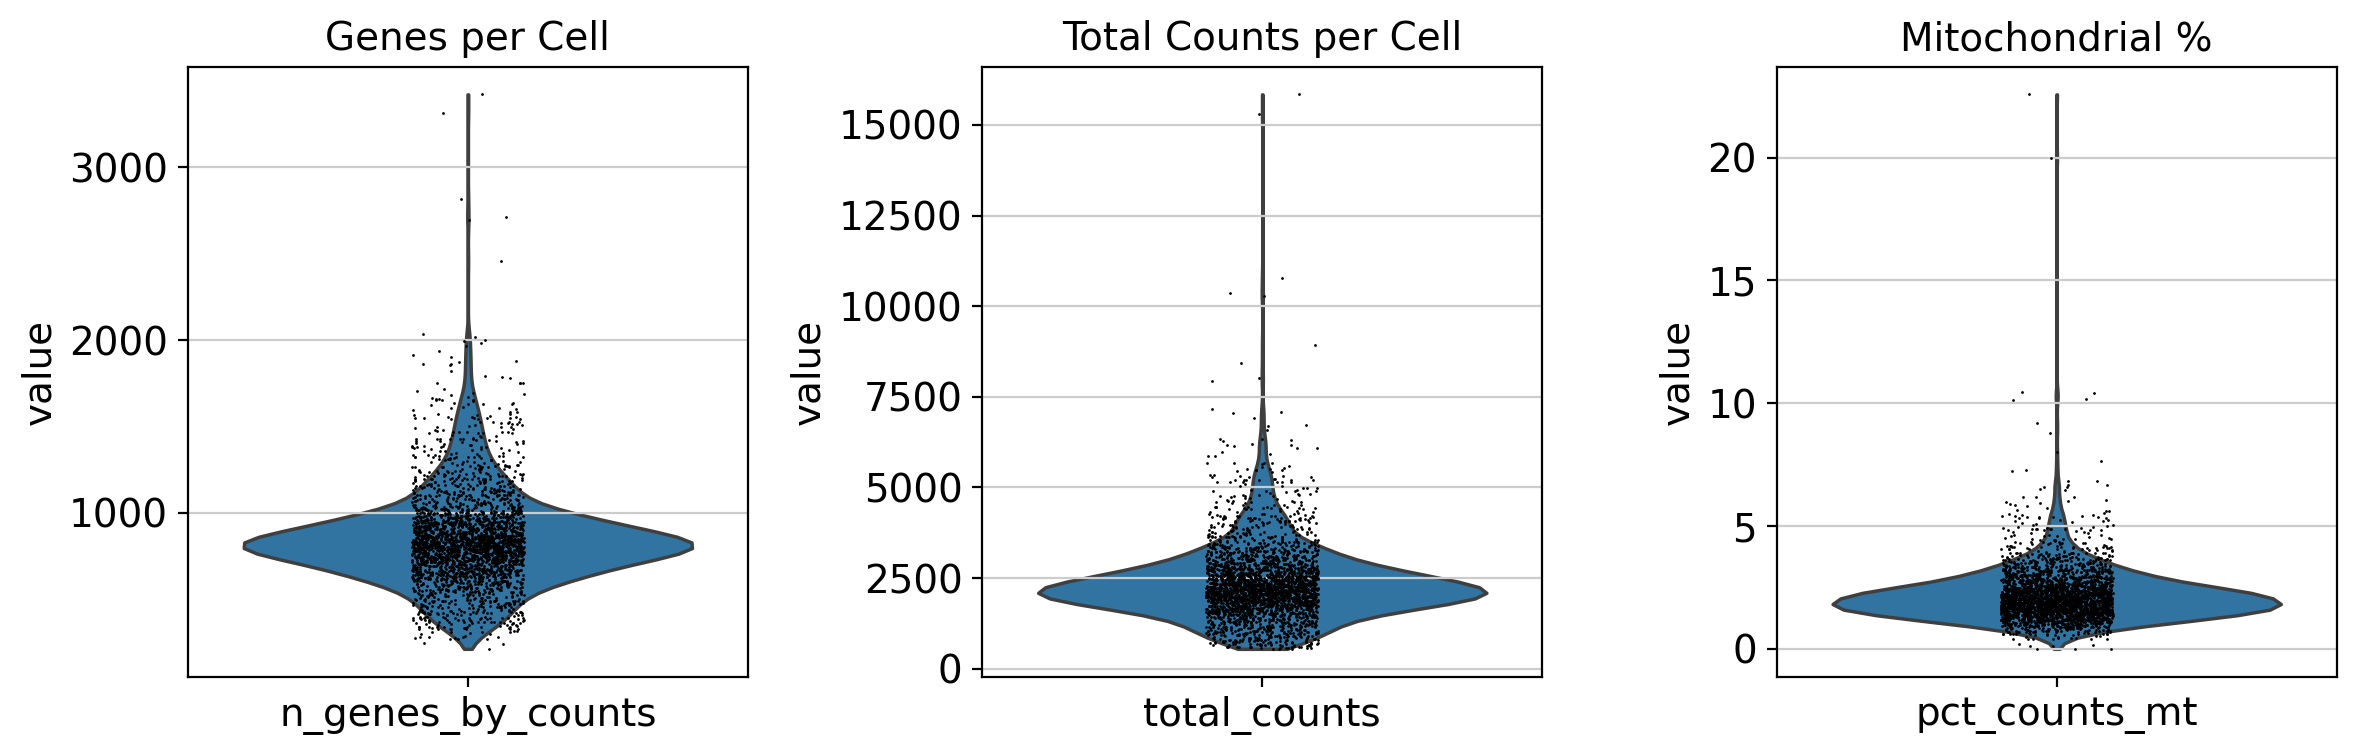

Before filtering: (2700, 32738)


In [ ]:
# Annotate mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

# Visualize QC metrics before filtering
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sc.pl.violin(adata, "n_genes_by_counts", ax=axes[0], show=False)
sc.pl.violin(adata, "total_counts", ax=axes[1], show=False)
sc.pl.violin(adata, "pct_counts_mt", ax=axes[2], show=False)
axes[0].set_title("Genes per Cell")
axes[1].set_title("Total Counts per Cell")
axes[2].set_title("Mitochondrial %")
plt.tight_layout()
plt.show()

print(f"Before filtering: {adata.shape}")

In [ ]:
# Apply filters
sc.pp.filter_cells(adata, min_genes=cfg.MIN_GENES)
sc.pp.filter_genes(adata, min_cells=cfg.MIN_CELLS)
adata = adata[adata.obs["n_genes_by_counts"] < cfg.MAX_GENES, :].copy()
adata = adata[adata.obs["pct_counts_mt"] < cfg.MAX_MT_PCT, :].copy()

print(f"After filtering: {adata.shape}")
print(f"  Removed {2700 - adata.n_obs} cells, kept {adata.n_obs}")

filtered out 19024 genes that are detected in less than 3 cells
After filtering: (2638, 13714)
  Removed 62 cells, kept 2638


## 3. Normalize and Log-Transform

**Why normalize?** Different cells are sequenced to different depths (total UMI counts vary).
Normalizing to a fixed total (10,000) makes cells comparable.

**Why log-transform?** Gene expression is heavily right-skewed (few genes very highly expressed).
Log-transform compresses the dynamic range and makes the data more amenable to linear methods like PCA.

In [ ]:
# Save raw counts before normalization
adata.layers["counts"] = adata.X.copy()

# Normalize: each cell sums to 10,000
sc.pp.normalize_total(adata, target_sum=cfg.NORMALIZE_TARGET)

# Log-transform: log(1 + x)
sc.pp.log1p(adata)
adata.layers["log_norm"] = adata.X.copy()

print(f"After normalization + log1p:")
X_dense = adata.X.toarray() if sp.issparse(adata.X) else adata.X
print(f"  Value range: [{X_dense.min():.2f}, {X_dense.max():.2f}]")
print(f"  Mean expression: {X_dense.mean():.4f}")
print(f"  Sparsity: {(X_dense == 0).mean():.1%} zeros")

normalizing counts per cell
    finished (0:00:00)
After normalization + log1p:
  Value range: [0.00, 7.47]
  Mean expression: 0.1254
  Sparsity: 93.8% zeros


## 4. Highly Variable Gene (HVG) Selection

Most genes have little variation across cells and are uninformative for distinguishing cell types.
We select the top 2,000 **highly variable genes** — genes whose expression varies the most across cells.

We use the `seurat_v3` method, which operates on raw counts and models the mean-variance relationship
to identify genes with higher-than-expected variance. This is more robust than the original `seurat`
method that operates on log-normalized data.

extracting highly variable genes
Highly variable genes: 2000 / 13714


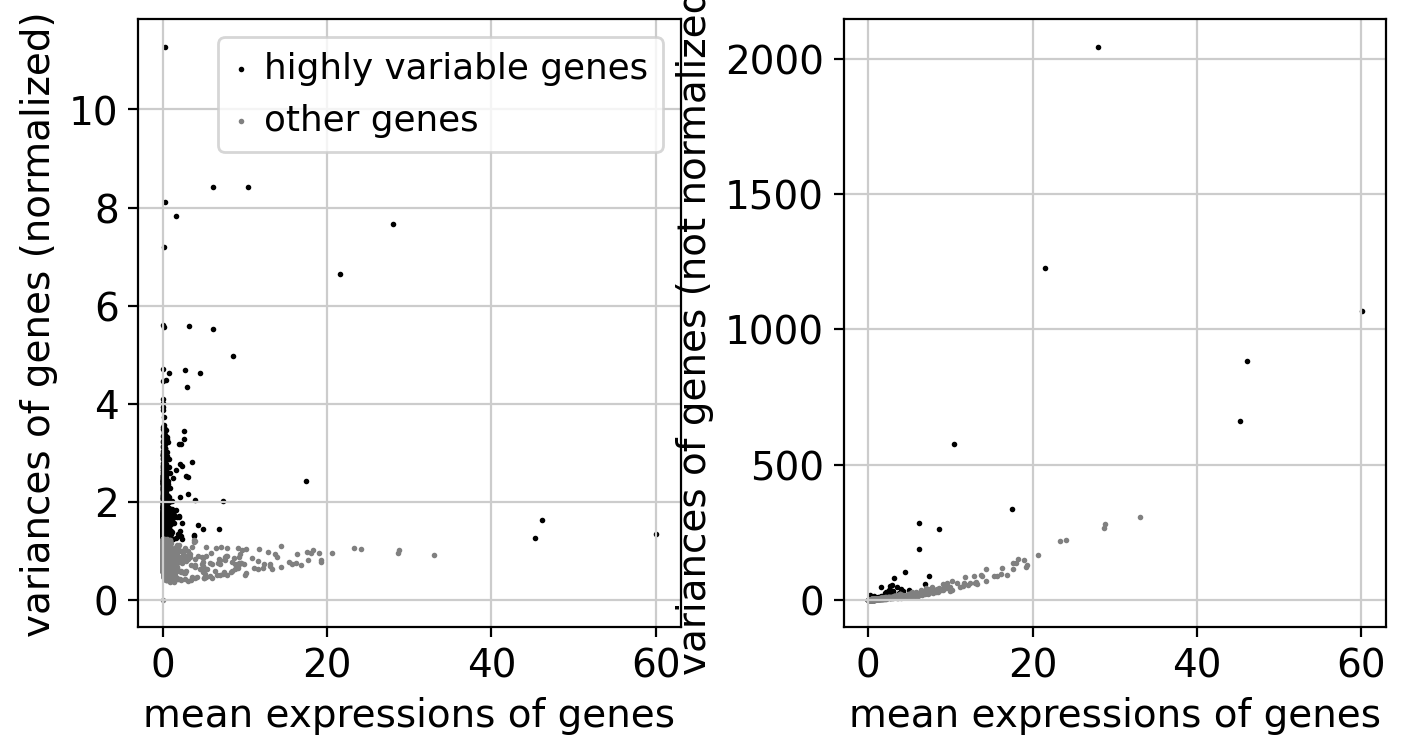


HVG subset shape: (2638, 2000)


In [ ]:
# HVG selection on raw counts
sc.pp.highly_variable_genes(
    adata,
    flavor=cfg.HVG_FLAVOR,
    n_top_genes=cfg.N_HVG,
    layer="counts",
)

print(f"Highly variable genes: {adata.var['highly_variable'].sum()} / {adata.n_vars}")
sc.pl.highly_variable_genes(adata)

# Subset to HVGs
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print(f"\nHVG subset shape: {adata_hvg.shape}")

## 5. PCA, UMAP, and Clustering (for Visualization)

**PCA** reduces the 2,000-gene space to 50 principal components that capture the most variance.
This makes neighbor-graph computation and UMAP tractable.

**UMAP** embeds the high-dimensional data into 2D for visualization,
preserving local neighborhood structure.

**Leiden clustering** identifies groups of cells with similar expression profiles.

computing PCA
    with n_comps=50


/home/zhuoyuan/miniconda3/envs/GenAI_single_cell/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:07)


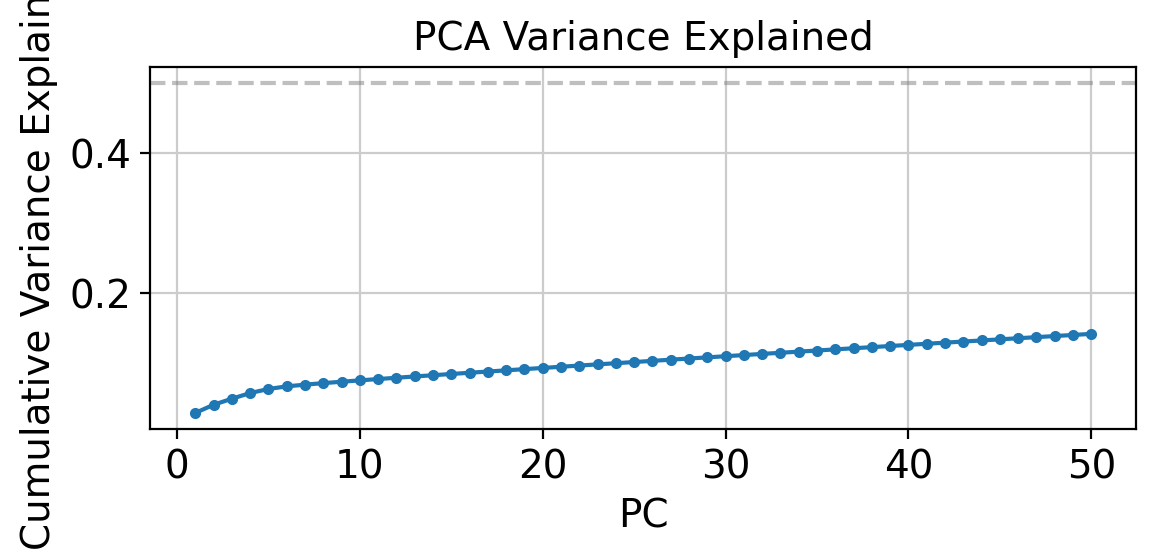

Top 20 PCs explain 9.3% of variance
Top 50 PCs explain 14.2% of variance


In [ ]:
# Scale for PCA (only for visualization; the modeling pipeline uses StandardScaler on train split)
adata_vis = adata_hvg.copy()
sc.pp.scale(adata_vis, max_value=10)
sc.tl.pca(adata_vis, n_comps=cfg.PCA_VIS_COMPS, svd_solver="arpack")

# Variance explained
cumvar = np.cumsum(adata_vis.uns["pca"]["variance_ratio"])
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, len(cumvar) + 1), cumvar, "o-", markersize=3)
ax.set_xlabel("PC")
ax.set_ylabel("Cumulative Variance Explained")
ax.set_title("PCA Variance Explained")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Top 20 PCs explain {cumvar[19]:.1%} of variance")
print(f"Top 50 PCs explain {cumvar[49]:.1%} of variance")

**Why is the cumulative variance so low (~10–15%)?**

This is **normal and expected** for scaled scRNA-seq data:

1. **Scaling redistributes variance.** `sc.pp.scale()` standardizes each of the 2,000 genes
   to unit variance, so total variance = 2,000. The top 50 PCs capturing ~14% means ~280
   out of 2,000 "units" — equivalent to what 280 independent genes could explain.

2. **scRNA-seq is genuinely high-dimensional.** Unlike image data where a few PCs dominate,
   gene expression has many independent biological programs (immune response, cell cycle,
   metabolism...) each affecting different gene sets.

3. **What matters is biological signal, not total variance.** The UMAP below shows clean
   cluster separation using these PCs — the top components captured the *biologically
   meaningful* variation (cell type differences), even if they miss per-gene noise.

4. **Without scaling**, you'd see ~30–50% in the top 50 PCs, but that's misleading — a few
   highly-expressed housekeeping genes would dominate the variance, drowning out the
   interesting biology.

computing neighbors
    using 'X_pca' with n_pcs = 40


/home/zhuoyuan/miniconda3/envs/GenAI_single_cell/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:06)
computing UMAP
    finished (0:00:02)
running Leiden clustering
    finished (0:00:00)


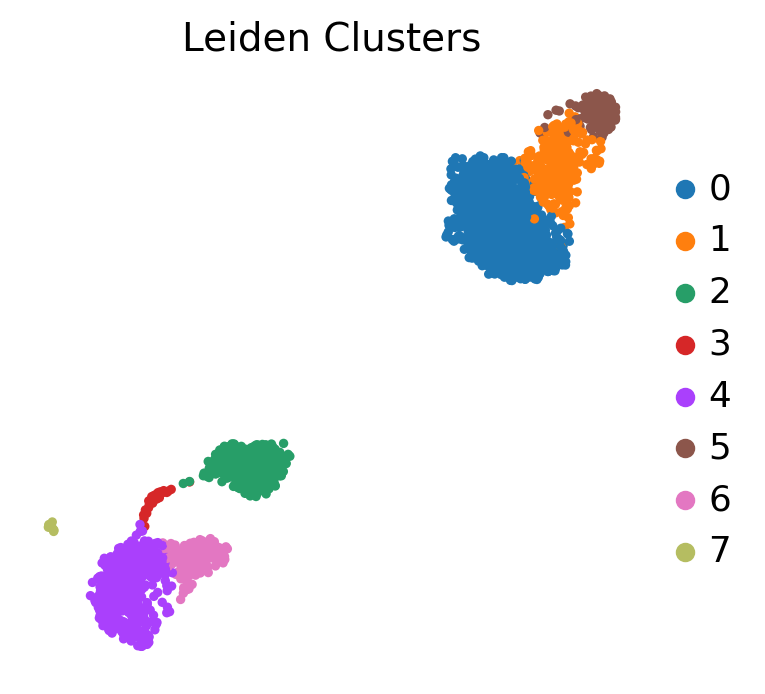

In [ ]:
# Neighbors, UMAP, Leiden
sc.pp.neighbors(adata_vis, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_vis)
sc.tl.leiden(
    adata_vis,
    resolution=0.7,
    random_state=cfg.SEED,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

sc.pl.umap(adata_vis, color="leiden", title="Leiden Clusters")

Marker genes found in HVGs: ['CST3', 'NKG7', 'MS4A1', 'LYZ', 'PPBP', 'FCER1A', 'FCGR3A', 'CD79A']


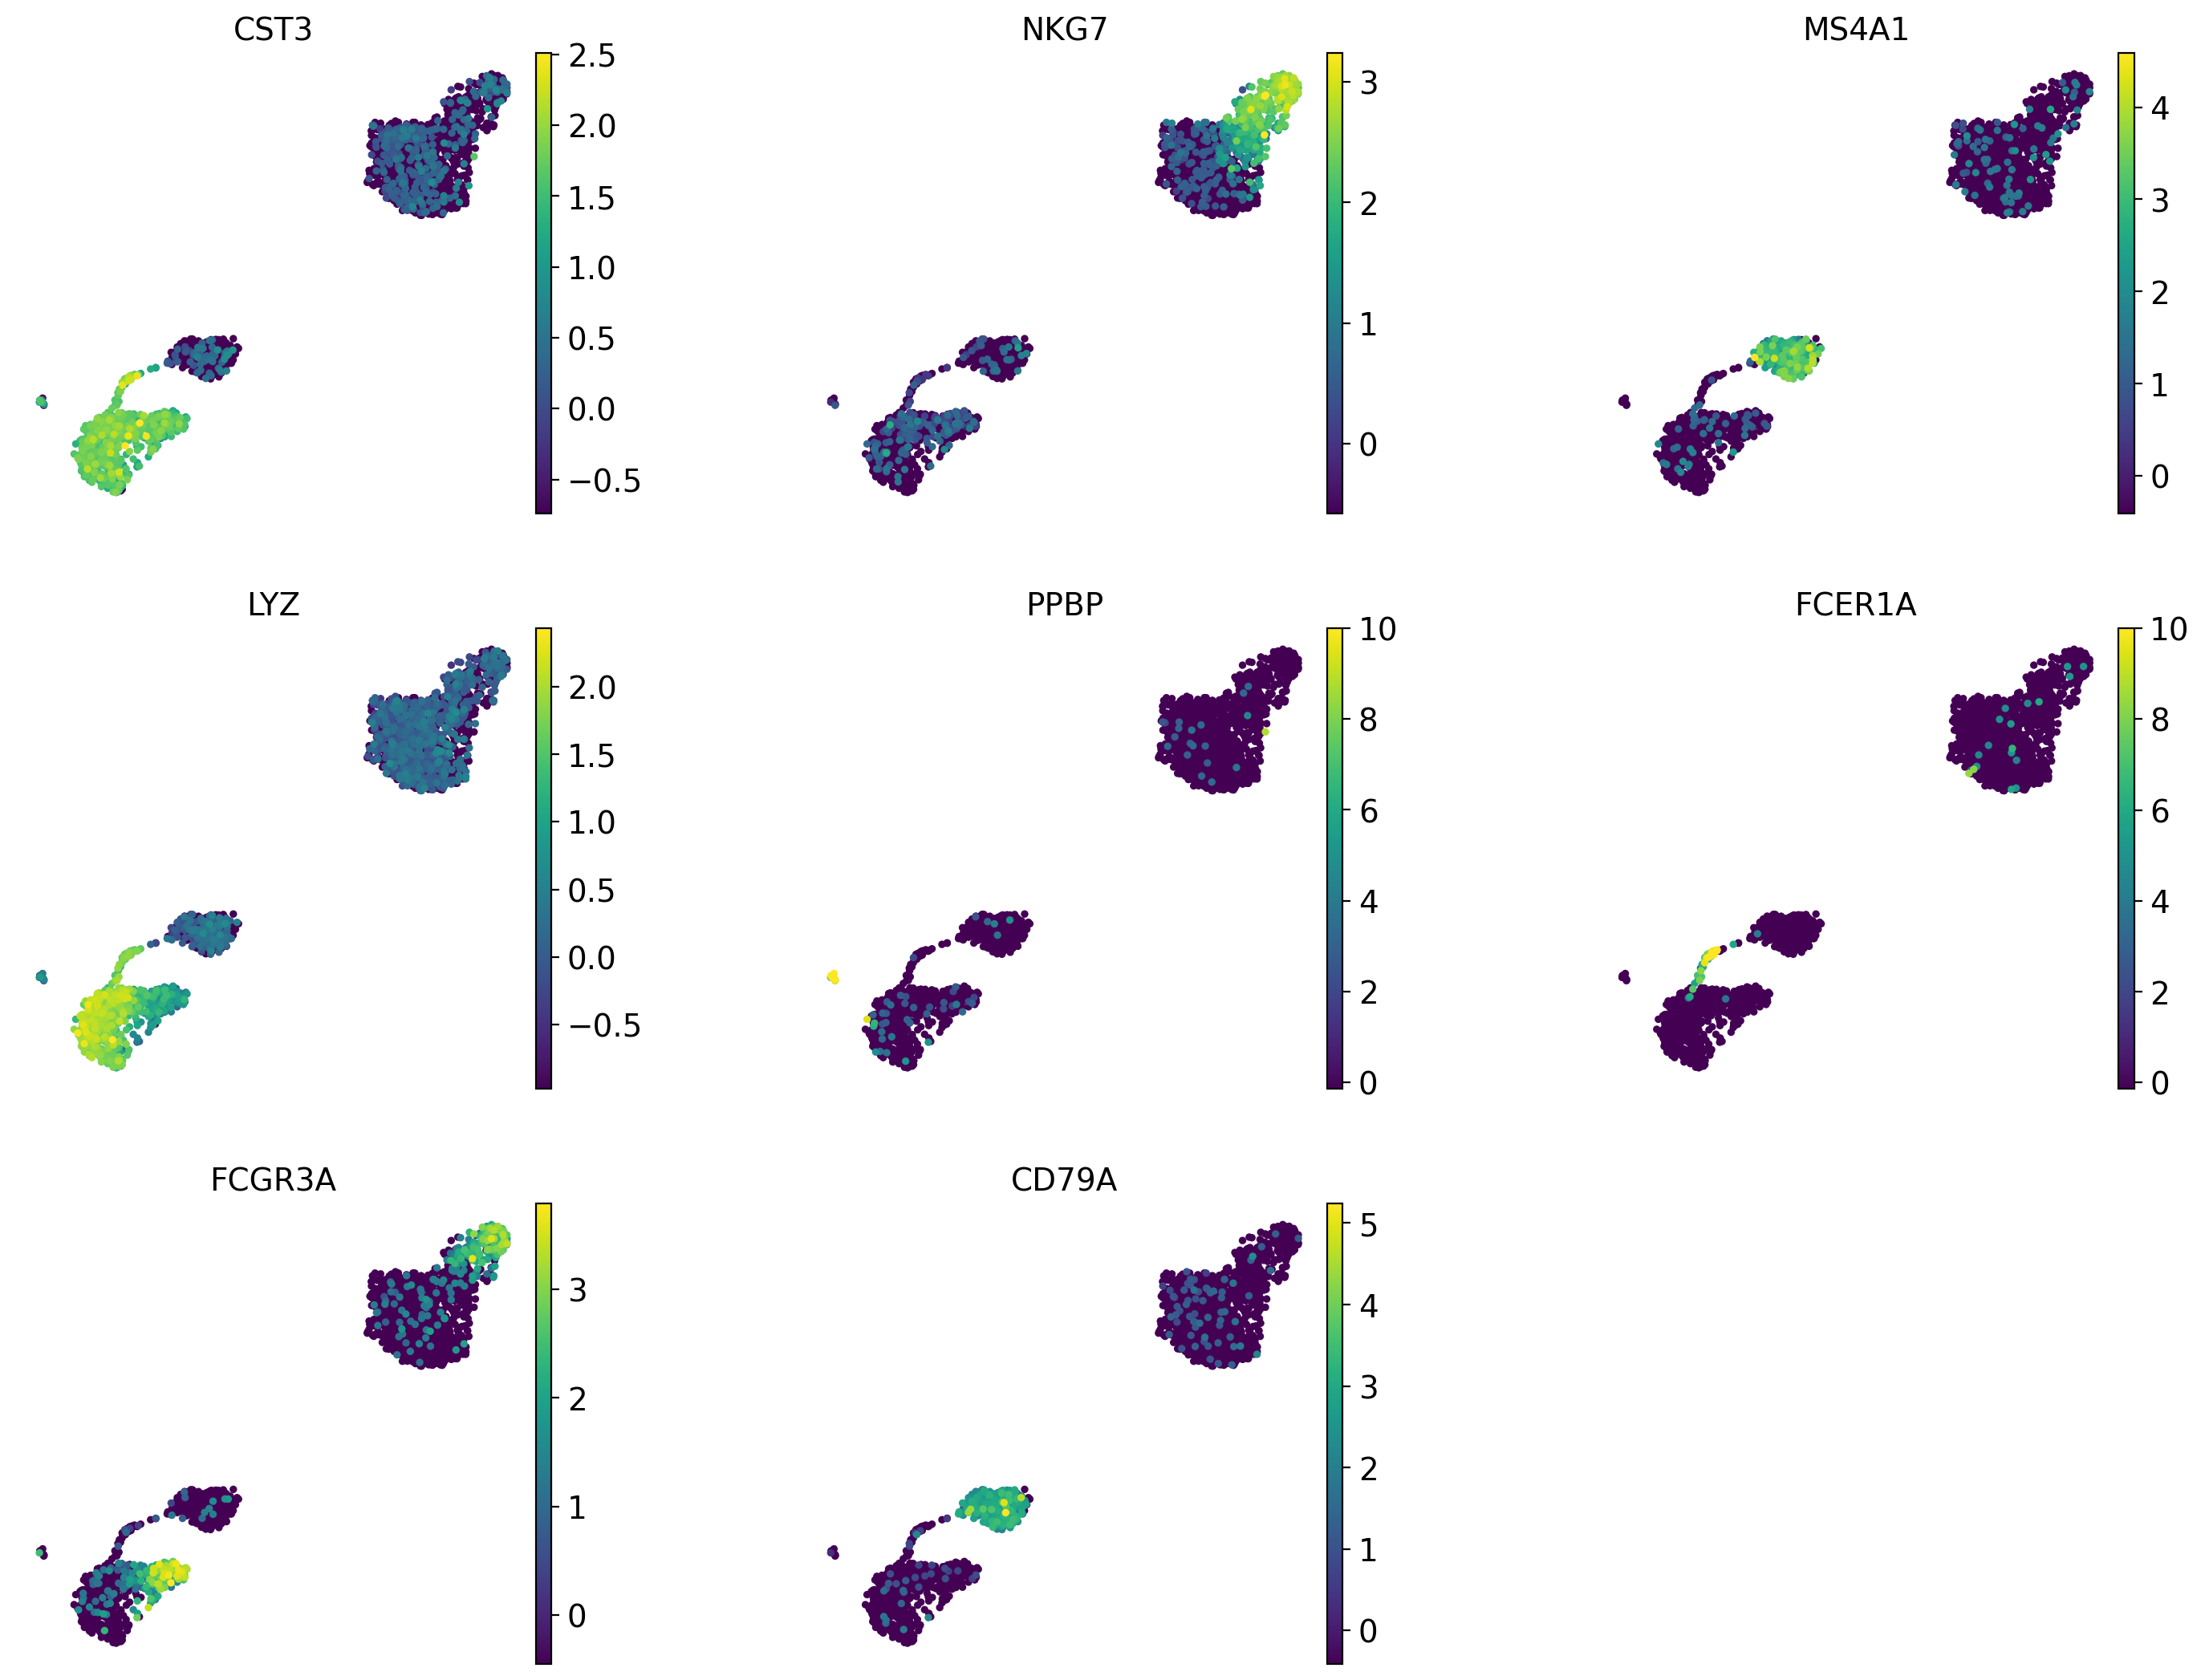

In [ ]:
# Marker gene visualization
marker_in_hvg = [g for g in cfg.MARKER_GENES if g in adata_vis.var_names]
print(f"Marker genes found in HVGs: {marker_in_hvg}")

sc.pl.umap(adata_vis, color=marker_in_hvg, ncols=3, wspace=0.4)

## 6. Extract Feature Matrix, Split, and Standardize

For our generative modeling pipelines, we need:
1. A dense float32 matrix of log-normalized HVG expression — shape `(n_cells, 2000)`
2. An 80/10/10 train/val/test split
3. StandardScaler fit **only on training data** (to avoid data leakage)

In [ ]:
# Extract dense feature matrix from log-normalized HVG data
X, hvg_names = extract_feature_matrix(adata_hvg)
print(f"Feature matrix: {X.shape}")
print(f"dtype: {X.dtype}")
print(f"Value range: [{X.min():.2f}, {X.max():.2f}]")
print(f"First 10 HVG names: {hvg_names[:10]}")

Feature matrix: (2638, 2000)
dtype: float32
Value range: [0.00, 7.47]
First 10 HVG names: ['ISG15', 'CPSF3L', 'MRPL20', 'ATAD3C', 'C1orf86', 'RER1', 'RP3-395M20.9', 'LRRC47', 'GPR153', 'TNFRSF25']


In [ ]:
# Split and standardize
split = split_and_scale(X)

print(f"Train: {split['X_train_s'].shape}")
print(f"Val:   {split['X_val_s'].shape}")
print(f"Test:  {split['X_test_s'].shape}")
print(f"\nStandardized train mean ~ 0: {split['X_train_s'].mean():.4f}")
print(f"Standardized train std  ~ 1: {split['X_train_s'].std():.4f}")

Train: (2110, 2000)
Val:   (263, 2000)
Test:  (265, 2000)

Standardized train mean ~ 0: -0.0000
Standardized train std  ~ 1: 0.9995


## 7. Save Processed Data

Save everything to `artifacts/data/` so that notebooks 02–04 can load it directly
without re-running preprocessing.

In [ ]:
save_processed(X, hvg_names, split)

print(f"Saved to {cfg.DATA_DIR}/")
for f in sorted(os.listdir(cfg.DATA_DIR)):
    size = os.path.getsize(os.path.join(cfg.DATA_DIR, f))
    print(f"  {f:25s} {size / 1024:.0f} KB")

Saved to /home/zhuoyuan/CSprojects/GenAI_SingleCell/artifacts/data/
  X_all.npy                 20610 KB
  X_all_s.npy               20610 KB
  X_gen_pca.npy             20610 KB
  X_test_s.npy              2070 KB
  X_train_s.npy             16484 KB
  X_val_s.npy               2055 KB
  hvg_names.json            19 KB
  scaler.joblib             47 KB
  test_idx.npy              2 KB
  train_idx.npy             17 KB
  val_idx.npy               2 KB


In [ ]:
print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Raw data:         2700 cells x 32738 genes")
print(f"After QC:         {adata.n_obs} cells x {adata.n_vars} genes")
print(f"After HVG:        {adata_hvg.n_obs} cells x {adata_hvg.n_vars} genes")
print(f"Train/Val/Test:   {split['X_train_s'].shape[0]} / {split['X_val_s'].shape[0]} / {split['X_test_s'].shape[0]}")
print(f"HVG method:       {cfg.HVG_FLAVOR} on raw counts")
print(f"Normalization:    target_sum={cfg.NORMALIZE_TARGET:.0f}, log1p")
print(f"Standardization:  StandardScaler fit on train only")
print(f"Saved to:         {cfg.DATA_DIR}/")
print("=" * 60)


PREPROCESSING SUMMARY
Raw data:         2700 cells x 32738 genes
After QC:         2638 cells x 13714 genes
After HVG:        2638 cells x 2000 genes
Train/Val/Test:   2110 / 263 / 265
HVG method:       seurat_v3 on raw counts
Normalization:    target_sum=10000, log1p
Standardization:  StandardScaler fit on train only
Saved to:         /home/zhuoyuan/CSprojects/GenAI_SingleCell/artifacts/data/
